# Model

In this notebook, we build a set of models to predict IMD in 2019 and compare them.

In [194]:
%matplotlib inline
import numpy as np
import pandas
import geopandas
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

## Data

In [197]:
# Read data
imd = pandas.read_csv('imd.csv', index_col='LSOA21CD')
socio = pandas.read_csv('Socioeconomic.csv', index_col='LSOA21CD')
manual = pandas.read_csv('landsat_features.csv', index_col='LSOA21CD')
lsoa = geopandas.read_file('uk_lsoa_london_embeds_2020.geojson').set_index('LSOA21CD')

# Column names and easy handles
embed_cols = [c for c in lsoa.columns if c.startswith('A') and c.endswith('_mean')]
embeds = pandas.DataFrame(lsoa[embed_cols])
socio_cols = [c for c in socio.columns if c != 'IMD_decile']

y = imd['imd19_score']
train = imd['train_test'] == 'train'

## Setup

We use a pre-defined spatial train/test split based on a regular grid overlaid on London (stored in `imd.csv`). Training LSOAs come from 80% of grid blocks; the remaining 20% are held out for testing. All models are fitted on training LSOAs and evaluated on test LSOAs using RMSE and $R^2$.

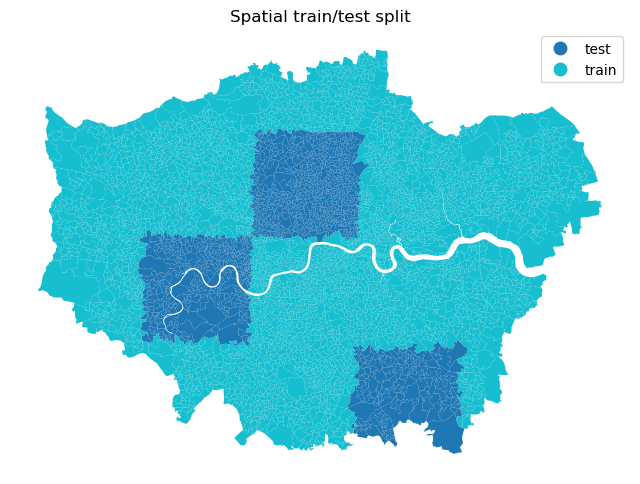

In [199]:
fig, ax = plt.subplots(figsize=(8, 8))
lsoa.join(imd[['train_test']]).plot(
    column='train_test', categorical=True, legend=True, ax=ax
)
ax.set_axis_off()
ax.set_title('Spatial train/test split')
plt.show()

To streamline model fitting, we define a helper method:

In [201]:
def fit_eval(X, y, train):
    idx = X.dropna().index.intersection(y.dropna().index)
    X, y_s, tr = X.loc[idx], y.loc[idx], train.loc[idx]
    pipe = make_pipeline(StandardScaler(), Ridge()) # we use Ridge not OLS (it minimises squared residuals but adds a penalty on large coefficients)
    pipe.fit(X[tr], y_s[tr])
    preds = pipe.predict(X[~tr])
    return {
        'RMSE': np.sqrt(mean_squared_error(y_s[~tr], preds)),
        'R²': r2_score(y_s[~tr], preds)
    }

And initialise the results store:

In [203]:
results = {}

## Models

### Socioeconomic data

In [207]:
results['Socioeconomic'] = fit_eval(socio[socio_cols], y, train)

### Manual features

In [213]:
results['Manual features'] = fit_eval(manual, y, train)

### Embeddings

In [216]:
results['Embeddings'] = fit_eval(embeds, y, train)

### Socioeconomic + Manual features

In [220]:
results['Socioeconomic + Manual'] = fit_eval(
    socio[socio_cols].join(manual, how='inner'), y, train
)

### Socioeconomic + Embeddings

In [223]:
results['Socioeconomic + Embeddings'] = fit_eval(
    socio[socio_cols].join(embeds, how='inner'), y, train
)

## Comparison

Here we build pretty tables to compare performance metrics (one for each, RMSE and $R^2$) across all models.

In [226]:
comparison = pandas.DataFrame(results).T.round(3)
comparison.index.name = 'Model'
comparison

,RMSE,R²
Model,,
Socioeconomic,6.647,0.693
Manual features,10.467,0.240
Embeddings,9.377,0.390
Socioeconomic + Manual,5.900,0.758
Socioeconomic + Embeddings,5.819,0.765


## Similarity in embedding space

A useful way to understand embeddings is not only to use them in a regression model, but to ask which neighbourhoods look similar **from the satellite model's perspective**.

In the cell below, choose one LSOA as an anchor, compute cosine similarity between its embedding vector and every other LSOA embedding, and map the result across London.

Cosine similarity compares the **angle** between two vectors rather than their absolute magnitude:

$$
\mathrm{cosine\ similarity}(a, b) = \frac{a \cdot b}{\|a\|\|b\|}
$$

Intuition:
- if two vectors point in almost the same direction, cosine similarity is close to 1
- if their directions differ more strongly, the similarity drops toward 0
- here that means two LSOAs can be geographically far apart, but still be similar if the embedding model sees them as visually similar neighbourhoods

What goes into the equation in practice:
- for one anchor LSOA, we take its full embedding row from `embeds`, for example `[A1_mean, A2_mean, A3_mean, ..., Ak_mean]`
- for every other LSOA, we take the corresponding embedding row with the same dimensions
- the dot product `a · b` multiplies matching dimensions and sums them
- the denominator divides by the vector lengths, so we compare **pattern** rather than overall scale
- so cosine similarity is asking: do these two neighbourhoods have similar embedding profiles across all learned dimensions?

In the comparison cell below, we stay inside the embedding space but restrict the calculation to only a subset of embedding dimensions. This helps show that an embedding is just a long learned vector, and that similarity can change depending on which dimensions we include.

What this shows:
- embeddings encode neighbourhood appearance in a high-dimensional space
- two LSOAs can be close in embedding space even if they are far apart geographically
- high similarity means the model thinks the neighbourhoods have similar visual/spectral context


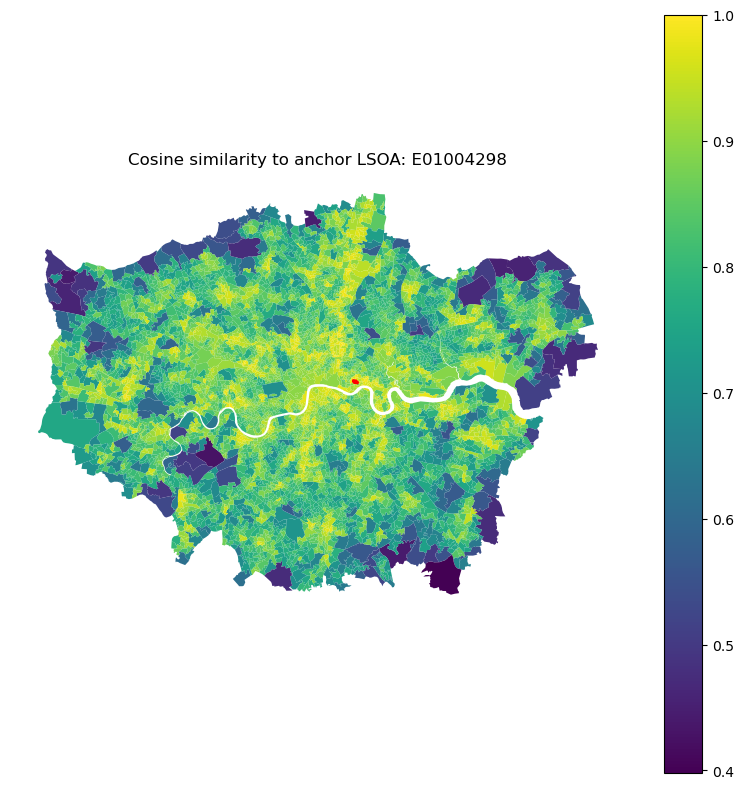

Anchor LSOA: E01004298

Top 5 most similar LSOAs:


,embedding_similarity
LSOA21CD,
E01035641,0.994594
E01033700,0.992728
E01004326,0.991547
E01001367,0.991075
E01004286,0.990977


In [229]:
# Change this LSOA code and rerun the cell to explore a different anchor neighbourhood.
anchor_lsoa = 'E01004298' # insert yours or embeds.index[0] as sample

anchor_vec = embeds.loc[anchor_lsoa].to_numpy(dtype=float)
embed_matrix = embeds.to_numpy(dtype=float)

# Cosine similarity = dot(a, b) / (||a|| ||b||)
anchor_norm = np.linalg.norm(anchor_vec)
all_norms = np.linalg.norm(embed_matrix, axis=1)
similarity = (embed_matrix @ anchor_vec) / (all_norms * anchor_norm)

similarity_df = pandas.DataFrame(
    {'embedding_similarity': similarity},
    index=embeds.index,
)

lsoa_similarity = lsoa.join(similarity_df)
anchor_geom = lsoa.loc[[anchor_lsoa]]

fig, ax = plt.subplots(figsize=(8, 8))
lsoa_similarity.plot(
    column='embedding_similarity',
    cmap='viridis',
    legend=True,
    ax=ax,
)
anchor_geom.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1.5)
ax.set_title(f'Cosine similarity to anchor LSOA: {anchor_lsoa}')
ax.set_axis_off()
plt.tight_layout()
plt.show()

top_matches = similarity_df.drop(index=anchor_lsoa).sort_values('embedding_similarity', ascending=False).head(5)
print('Anchor LSOA:', anchor_lsoa)
print('\nTop 5 most similar LSOAs:')
top_matches

Available embedding columns:
['A00_mean', 'A01_mean', 'A02_mean', 'A03_mean', 'A04_mean', 'A05_mean', 'A06_mean', 'A07_mean', 'A08_mean', 'A09_mean', 'A10_mean', 'A11_mean', 'A12_mean', 'A13_mean', 'A14_mean', 'A15_mean', 'A16_mean', 'A17_mean', 'A18_mean', 'A19_mean', 'A20_mean', 'A21_mean', 'A22_mean', 'A23_mean', 'A24_mean', 'A25_mean', 'A26_mean', 'A27_mean', 'A28_mean', 'A29_mean', 'A30_mean', 'A31_mean', 'A32_mean', 'A33_mean', 'A34_mean', 'A35_mean', 'A36_mean', 'A37_mean', 'A38_mean', 'A39_mean', 'A40_mean', 'A41_mean', 'A42_mean', 'A43_mean', 'A44_mean', 'A45_mean', 'A46_mean', 'A47_mean', 'A48_mean', 'A49_mean', 'A50_mean', 'A51_mean', 'A52_mean', 'A53_mean', 'A54_mean', 'A55_mean', 'A56_mean', 'A57_mean', 'A58_mean', 'A59_mean', 'A60_mean', 'A61_mean', 'A62_mean', 'A63_mean']

Selected embedding dimensions for the subset map:
['A00_mean', 'A05_mean', 'A06_mean', 'A07_mean', 'A12_mean', 'A16_mean', 'A42_mean', 'A43_mean', 'A51_mean']


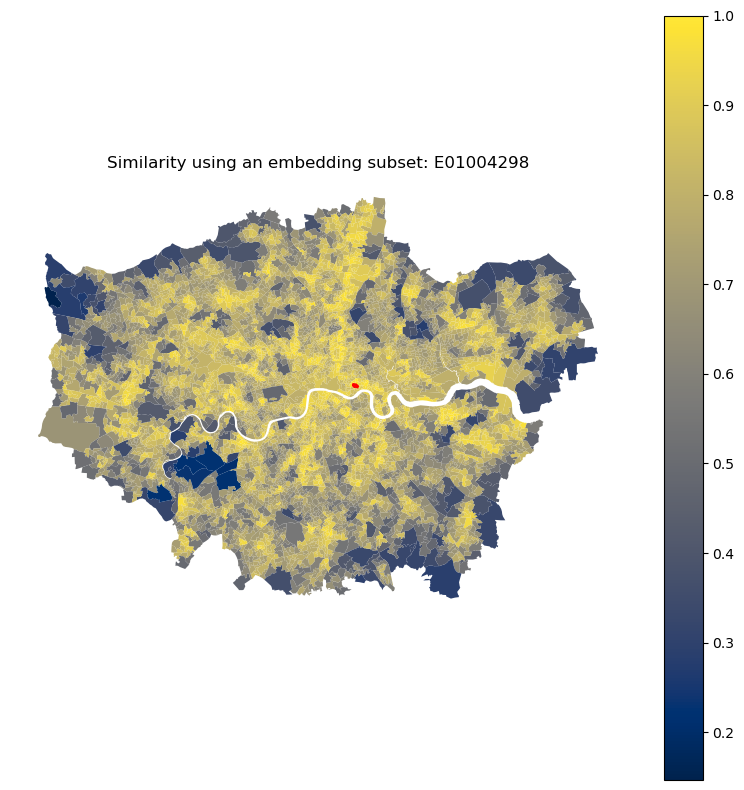

In [230]:
# Compare the full-embedding similarity map with a second map that uses only
# a subset of embedding dimensions. This keeps the comparison inside the
# embedding space rather than switching to manual Landsat features.

# First show the available embedding columns in the dataset.
print('Available embedding columns:')
print(embed_cols)

# Now choose a smaller subset of embedding dimensions.
# Change this list if you want to test a different subset.
# or select them more random like 
#embed_cols ['A00_mean', 'A01_mean', 'A02_mean', 'A03_mean', 'A04_mean', 'A05_mean', 
# 'A06_mean', 'A07_mean', 'A12_mean', 'A13_mean', 'A14_mean', 'A15_mean', 'A16_mean', 'A42_mean', 'A43_mean', 'A51_mean']

selected_embed_cols = ['A00_mean', 'A05_mean','A06_mean', 'A07_mean', 'A12_mean', 'A16_mean', 'A42_mean', 'A43_mean', 'A51_mean']
print('\nSelected embedding dimensions for the subset map:')
print(selected_embed_cols)

# Keep only the chosen embedding columns and drop rows with missing values.
embed_subset = embeds.loc[:, selected_embed_cols].dropna()

# Extract the anchor LSOA row as a numeric vector.
# Practically, this is something like:
# [A1_mean, A2_mean, ..., A10_mean] for the chosen area, depending on the subset.
anchor_subset_vec = embed_subset.loc[anchor_lsoa].to_numpy(dtype=float)

# Convert the selected embedding table into a matrix where each row is one LSOA
# and each column is one of the selected embedding dimensions.
subset_matrix = embed_subset.to_numpy(dtype=float)

# Compute vector lengths for the cosine similarity denominator.
anchor_subset_norm = np.linalg.norm(anchor_subset_vec)
subset_norms = np.linalg.norm(subset_matrix, axis=1)

# Compute cosine similarity between the anchor vector and every LSOA row.
# The matrix multiplication subset_matrix @ anchor_subset_vec is the batch version
# of the dot product with the anchor across all rows at once.
subset_similarity = (subset_matrix @ anchor_subset_vec) / (subset_norms * anchor_subset_norm)

# Store the similarity scores in a DataFrame indexed by LSOA code.
subset_similarity_df = pandas.DataFrame(
    {'subset_embedding_similarity': subset_similarity},
    index=embed_subset.index,
)

# Join the similarity values back to the LSOA geometry so they can be mapped.
lsoa_subset_similarity = lsoa.join(subset_similarity_df)

# Plot the subset-embedding similarity map and highlight the anchor area in red.
fig, ax = plt.subplots(figsize=(8, 8))
lsoa_subset_similarity.plot(
    column='subset_embedding_similarity',
    cmap='cividis',
    legend=True,
    ax=ax,
)
anchor_geom.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1.5)
ax.set_title(f'Similarity using an embedding subset: {anchor_lsoa}')
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Exercise
Try changing `anchor_lsoa` and rerunning both maps.

Suggested questions:
- how different is the full-embedding map from the subset-embedding map?
- which kinds of areas stay similar even when you restrict the embedding dimensions?
- what does that suggest about how the information is distributed across the embedding vector?

Example LSOAs to try:
- Covent Garden: E01004734
- Hyde Park: E01035718
- Tower Hamlets: E01004298

You can also use this [link](https://jamestrimble.github.io/imdmaps/eimd2015/) to explore IMD scores and LSOAs interactively in London